In [1]:
import pandas as pd
from utils.misc import cols_to_front
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os
from sklearn.feature_extraction.text import TfidfTransformer
from utils.misc import cols_to_front
import yaml
with open('config/config.yaml', 'r') as file:
    config = yaml.safe_load(file)

# Ensure output dir exists
output_dir = config['output_dir']
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Import data
merged_df = pd.read_csv('data/merged_ai_descriptors_clean.csv')
df1 = pd.read_csv('data/merged_ai_descriptors_dummies_filtered.csv')

In [3]:
# Get column names
desc = [
    c for c in df1.columns
    if c != "Nom scientifique" and "cat_" not in c and 'category' not in c and 'db' not in c
]
desc_og = desc
cat_cols = [c for c in df1.columns if "cat_" in c]
name = "Nom scientifique"

In [4]:
merged_df['category'] = merged_df['sub_category'].copy()

In [5]:
df1 = df1.merge(
    merged_df[["Nom scientifique", "category", "db"]].drop_duplicates("Nom scientifique"),
    on="Nom scientifique",
    how="left",
    validate="many_to_one"  # optional but recommended
)

df1 = cols_to_front(df1, ['Nom scientifique', 'category'])

df1_og = df1.copy(deep=True)
df1.head()

,Nom scientifique,category,acid,airy,anise,apple,aroma,astringent,bean,beef,...,cat_beverage,cat_fruit,cat_fungus,cat_grains,cat_nuts,cat_plant,cat_prepared food,cat_tuber,cat_vegetable,db
0,Macrocystis pyrifera,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
1,Palmaria palmata,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
2,Porphyra perforata,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
3,Porphyra abbottae,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local
4,Porphyra torta,plant,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,local


# Overview

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of columns > 0 for each row
row_nonzero_counts = df1[desc].sum(axis=1)

if config['show_plot']:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(row_nonzero_counts, bins=20)
    plt.xlabel('Number descriptors', fontsize=12)
    plt.ylabel('Number of ingredients', fontsize=12)
    plt.title('Number of descriptors per ingredients', fontsize=14)
    plt.grid(False)

    save_path = os.path.join("output", "stats_nbr_descriptor_per_ing.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [7]:
# Number of ingredient where each ai descriptor is used
non_null_counts = df1[desc].sum()

if config['show_plot']:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(non_null_counts, bins=20)
    plt.xlabel('Number of ingredients', fontsize=12)
    plt.ylabel('Number of descriptors', fontsize=12)
    plt.title('Number of descriptor per ingredient', fontsize=14)
    plt.grid(False)

    save_path = os.path.join("output", "stats_nbr_of ingredients_per_descriptor.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [8]:
# Number of ingredient where each ai descriptor is used
non_null_counts.sort_values(ascending=False).head(20)

sweet       957
earth       716
nut         453
fresh       402
bitter      365
savory      288
tang        277
delicate    265
aroma       264
grass       252
butter      243
floral      234
umami       227
cream       219
spicy       208
fruit       207
tender      192
vegetal     192
crisp       190
juice       180
dtype: int64

In [9]:
# Number of ingredient where each ai descriptor is used
cat_flavors = {}
cat_flav10 = {}
df2 = df1[desc+["category"]].groupby('category').sum()

for cat in df2.index.unique():
    cat_flavors[cat] =  df2.loc[cat].sort_values(ascending=False)
    cat_flav10[cat] = cat_flavors[cat].head(10)


# Category definition

## Custom categories

In [10]:
lexicon = {'plant': 'plant',
 'animal product': 'animal product',
 'fungus': 'fungus',
 'beverage': 'beverage',
 None: None,
 'vegetable': 'vegetable',
 'dish': 'dish',
 'vegetable-root': 'root',
 'fruit': 'fruit',
 'herb': 'herb',
 'additive': 'additive',
 'cereal': 'cereal',
 'flower': 'flower',
 'bakery': 'bakery',
 'beverage alcoholic': 'beverage alcoholic',
 'beverage caffeinated': 'beverage',
 'maize': 'cereal',
 'dairy': 'dairy',
 'essential oil': 'essential oil',
 'berry': 'berry',
 'seafood': 'seafood',
 'fish': 'seafood',
 'fruit-berry': 'berry',
 'fruit citrus': 'fruit citrus',
 'fruit essence': 'essential oil',
 'meat': 'animal product',
 'nut': 'nut',
 'seed': 'nut',
 'legume': 'legume',
 'plant derivative': 'plant derivative',
 'spice': 'spice',
 'cabbage': 'vegetable',
 'vegetable root': 'root',
 'vegetable fruit': 'vegetable fruit',
 'gourd': 'gourd',
 'vegetable stem': 'vegetable',
 'vegetable tuber': 'root'}

lexicon_og = {cat: cat for cat in df1['category'].dropna().unique()}  # make og dict

In [11]:
df1['category'] = df1['category'].map(lexicon).fillna(df1['category'])

In [12]:
cat_to_drop = ['animal product','dish', 'bakery', 'beverage alcoholic', 'dairy' ,'seafood' ]
df1 = df1[~df1['category'].isin(cat_to_drop)]

## FoodDB categories

In [13]:
foodb = pd.read_csv("data/foodb_food_cat_list.csv")

foodb['name'] = foodb['name'].str.lower()
group_dict = foodb.set_index('name')['food_group'].to_dict()
subgroup_dict = foodb.set_index('name')['food_subgroup'].to_dict()

In [14]:
# df1['Nom scientifique'] = df1['Nom scientifique'].str.lower()
# df1['category'] = df1['Nom scientifique'].map(group_dict).fillna(df1['category'])

# df1['category'] = df1['category'].str.lower()

In [15]:
# cat = 'plant derivative'
# df1.loc[df1['category'] == cat]

In [16]:
# df1 = df1.loc[df1['db'] != 'local']

In [17]:
# df1 = df1.loc[df1['db'] == 'local']
# df1.loc[df1['category'] == 'fruit']

In [18]:
# Keep only categories that appear at least 3 times
category_counts = df1['category'].value_counts()
df1 = df1[df1['category'].isin(category_counts[category_counts >= 3].index)]

In [19]:
if config['show_plot']:
    # --- Build feature matrix (drop identifiers and one-hot category columns) ---
    df_features = df1[desc]
    df_features = df_features.drop(columns=[c for c in df_features.columns if "cat_" in c], errors='ignore')

    # Keep only numeric columns (t-SNE requires numbers)
    df_features = df_features.select_dtypes(include=[np.number])

    # Handle NaNs
    df_features = df_features.fillna(0.0)

    # Optional: scale features (recommended for t-SNE)
    X = StandardScaler().fit_transform(df_features.values)

    # --- Align categories from merged_df to df1 rows ---
    name_series = df1['Nom scientifique']
    categories = df1['category']

    # --- Fit t-SNE ---
    tsne = TSNE(
        n_components=2,
        perplexity=min(30, max(5, (len(df_features) - 1) // 3)),  # decent auto heuristic
        learning_rate='auto',
        init='pca',
        metric='euclidean',
        random_state=42,
    )
    tsne_embedding = tsne.fit_transform(X)

    # --- Prepare DataFrame for plotting ---
    tsne_df = pd.DataFrame(tsne_embedding, columns=['tSNE1', 'tSNE2'])
    tsne_df['category'] = categories.values

    # --- Plot ---
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=tsne_df,
        x='tSNE1',
        y='tSNE2',
        hue='category',
        s=50,
        alpha=0.8
    )
    plt.title('t-SNE projection of Ingredient Categories', fontsize=18)
    plt.xlabel('tSNE1', fontsize=14)
    plt.ylabel('tSNE2', fontsize=14)
    plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [20]:
def jaccard_similarity_matrix(df_bin: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Jaccard similarity for all pairs of rows in a binary DataFrame.
    """
    X = df_bin.to_numpy(dtype=int)
    n = X.shape[0]

    sim = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i, n):
            intersection = np.logical_and(X[i], X[j]).sum()
            union = np.logical_or(X[i], X[j]).sum()
            sim_val = intersection / union if union != 0 else 0
            sim[i, j] = sim_val
            sim[j, i] = sim_val

    return pd.DataFrame(sim, index=df_bin.index, columns=df_bin.index)

# Compute Jaccard similarity matrix
jaccard_sim = jaccard_similarity_matrix(df1[desc])

# Average similarity per category
jaccard_sim['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim.groupby('category').mean()
jaccard_sim_mean = jaccard_sim_mean.T
jaccard_sim_mean['category'] = df1['category'].values
jaccard_sim_mean = jaccard_sim_mean.groupby('category').mean()

# if config['show_plot']:
#     plt.figure(figsize=(10, 8))
#     sns.heatmap(jaccard_sim_mean, cmap="coolwarm", vmin=0, vmax = 0.5)
#     plt.title("Mean Jaccard Similarity of ingredients in each category")
#     plt.show()


In [21]:
if config['show_plot']:
    # --- Cluster the category-level similarity matrix ---
    sns.clustermap(
        jaccard_sim_mean,
        cmap="coolwarm",
        vmin=0, vmax=0.5,
        method="ward",
        metric="euclidean",
        figsize=(10, 8)
    )

    plt.suptitle("Clustered Jaccard Similarity of Ingredient Categories", y=1.02)
    plt.show()

In [22]:
cat = 'seafood'
df1.loc[df1['category'] == cat]
print(df1.loc[df1['category'] == cat]['Nom scientifique'].values)

[]


In [23]:
df1['category'].value_counts()

category
plant               113
fruit                90
root                 61
herb                 57
vegetable            52
essential oil        43
berry                43
additive             32
cereal               31
nut                  26
fungus               25
spice                25
legume               23
beverage             21
plant derivative     20
flower               12
fruit citrus         10
gourd                 7
vegetable fruit       4
Name: count, dtype: int64

# Dimensionality reduction

## SVD

In [24]:
# --- Copy + select one-hot columns ---
df = df1.copy(deep=True)
X = df[desc].to_numpy()   # PCA expects dense (numpy array)
cols = df[desc].columns
n_components = config['n_dim']

In [25]:
# SVD
if config['reduce_dim_method'] == 'svd':
    # --- Truncated SVD ---    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    if config['idf']:    #IDF Seems to lead to worst fitting of dims by SVD
        tfidf = TfidfTransformer(norm=None, use_idf=True, smooth_idf=True, sublinear_tf=False)
        X = tfidf.fit_transform(X)  # stays sparse
    X_svd = svd.fit_transform(X)

    if config['reduce_dim'] == True:
        # --- Replace desc columns with SVD components in df ---
        dim_cols = [f"svd_{i+1:03d}" for i in range(n_components)]
        df.drop(columns=desc, inplace=True)
        df[dim_cols] = X_svd
        df1_dim_reduced = df.copy(deep=True)

## PCA

In [26]:
# PCA
if config['reduce_dim_method'] == 'pca':
    # --- Optional scaling (recommended for PCA) ---
    # For one-hot/binary features, scaling is optional, but PCA often behaves better with scaling.
    if config.get("pca_scale", True):
        scaler = StandardScaler(with_mean=True, with_std=True)
        X = scaler.fit_transform(X)

    # --- PCA (pick n components) ---
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X)

    if config["reduce_dim"] == True:
        # --- Replace desc columns with PCA components in df ---
        dim_cols = [f"pca_{i+1:03d}" for i in range(n_components)]
        df.drop(columns=desc, inplace=True)
        df[dim_cols] = X_pca
        df1_dim_reduced = df.copy(deep=True)

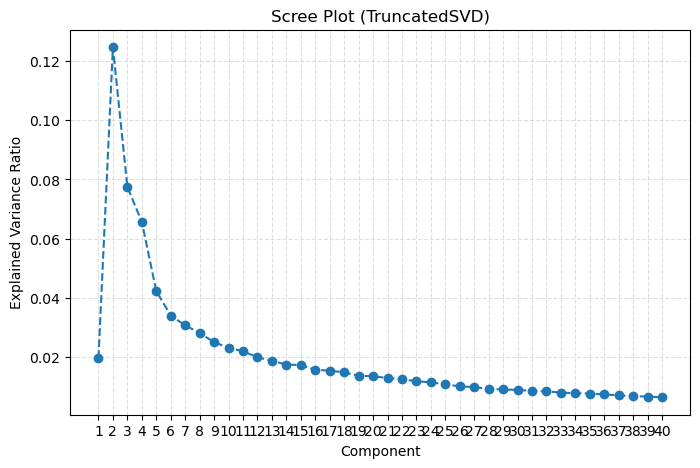

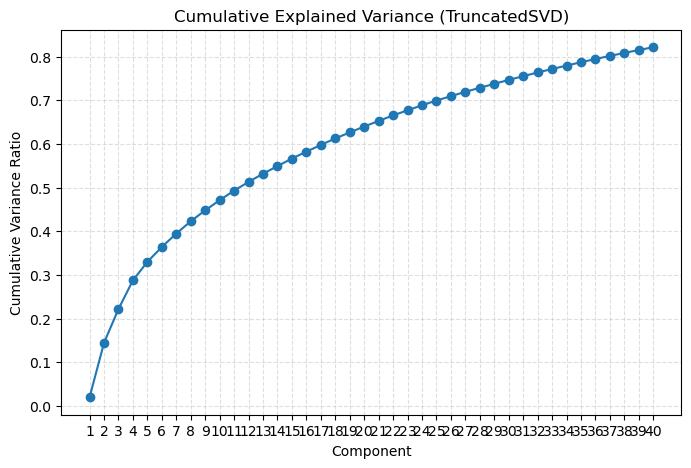

In [27]:
# --- Scree plot ---
if config["reduce_dim_method"] == "svd":
    model = svd
    method_label = "TruncatedSVD"
elif config["reduce_dim_method"] == "pca":
    model = pca
    method_label = "PCA"
else:
    raise ValueError(f"Unknown reduce_dim_method: {config['reduce_dim_method']} (expected 'svd' or 'pca')")

# Both PCA and TruncatedSVD provide explained_variance_ratio_
explained_var = model.explained_variance_ratio_

k = min(config["scree_max_dim"], len(explained_var))
dims = np.arange(1, k + 1)

os.makedirs("output", exist_ok=True)

# --- Scree plot ---
plt.figure(figsize=(8, 5))
plt.plot(dims, explained_var[:k], marker="o", linestyle="--")
plt.title(f"Scree Plot ({method_label})")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(dims)
plt.grid(True, linestyle="--", alpha=0.4)

save_path = os.path.join("output", f"scree_plot_{method_label}.png")
plt.savefig(save_path, dpi=config.get("dpi", 300), bbox_inches="tight")
if config.get("show_plot", False):
    plt.show()
# plt.close()

# --- Cumulative explained variance ---
plt.figure(figsize=(8, 5))
plt.plot(dims, np.cumsum(explained_var[:k]), marker="o")
plt.title(f"Cumulative Explained Variance ({method_label})")
plt.xlabel("Component")
plt.ylabel("Cumulative Variance Ratio")
plt.xticks(dims)
plt.grid(True, linestyle="--", alpha=0.4)

save_path = os.path.join("output", f"scree_plot_cum_{method_label}.png")
plt.savefig(save_path, dpi=config.get("dpi", 300), bbox_inches="tight")
if config.get("show_plot", False):
    plt.show()


## Save component top features

In [28]:
# Get features of top components
if config["reduce_dim_method"] == "pca":
    loadings = pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)], index=cols)
if config["reduce_dim_method"] == "svd":
    loadings = pd.DataFrame(svd.components_.T, columns=[f"SVD{i+1}" for i in range(svd.n_components)], index=desc)

if 'loadings' in globals():
    top_features = {}

    for pc in loadings.columns[:20]:
        top10 = (
            loadings[pc]
            .nlargest(10)               # top 10
        )
        top_features[pc] = top10.index.tolist()

    # Print nicely
    for pc, features in top_features.items():
        print(f"{pc} top 10 features: {features}")

    # pc_theme = ["fruity", "earthy", "savory", "creamy", "Sour", "Spicy", "Toasted", "Oceanic", "Floral", "bright"]


SVD1 top 10 features: ['sweet', 'earth', 'bitter', 'nut', 'fresh', 'aroma', 'grass', 'floral', 'vegetal', 'tang']
SVD2 top 10 features: ['tang', 'tart', 'fruit', 'juice', 'fresh', 'floral', 'citrus', 'aroma', 'acid', 'bright']
SVD3 top 10 features: ['aroma', 'spicy', 'herb', 'bitter', 'pungent', 'pepper', 'wood', 'resin', 'citrus', 'pine']
SVD4 top 10 features: ['fresh', 'grass', 'crisp', 'vegetal', 'green', 'bitter', 'astringent', 'tender', 'mineral', 'water']
SVD5 top 10 features: ['tang', 'bitter', 'savory', 'umami', 'salt', 'tart', 'astringent', 'mineral', 'brine', 'vegetal']
SVD6 top 10 features: ['astringent', 'grass', 'bitter', 'nut', 'tart', 'sour', 'starch', 'fruit', 'toast', 'malty']
SVD7 top 10 features: ['wood', 'pine', 'astringent', 'resin', 'herb', 'citrus', 'umami', 'fresh', 'smoke', 'mineral']
SVD8 top 10 features: ['floral', 'vegetal', 'green', 'honey', 'bitter', 'mineral', 'grass', 'tropical', 'salt', 'brine']
SVD9 top 10 features: ['bitter', 'cream', 'citrus', 'aroma

In [29]:
# saving
# ---- settings ----
top_n = 10
use_first_k_pcs = 20  # adjust as needed

# ---- pick model (PCA preferred if both exist) ----
if "pca" in globals() and hasattr(pca, "components_") and hasattr(pca, "explained_variance_ratio_"):
    model = pca
    prefix = "PC"
elif "svd" in globals() and hasattr(svd, "components_") and hasattr(svd, "explained_variance_ratio_"):
    model = svd
    prefix = "SVD"
else:
    raise NameError("Neither a fitted `pca` nor a fitted `svd` was found in globals().")

# ---- build loadings if not already defined ----
# Assumes you have `cols` (descriptor names). If not, fall back to `desc`.
if "loadings" not in globals() or loadings is None:
    feat_names = cols if "cols" in globals() else desc_og
    loadings = pd.DataFrame(
        model.components_.T,
        columns=[f"{prefix}{i+1}" for i in range(model.n_components)],
        index=feat_names,
    )

# ---- extract top features ----
pcs = loadings.columns[:use_first_k_pcs]
top_features = {pc: loadings[pc].nlargest(top_n).index.tolist() for pc in pcs}

top10_wide = pd.DataFrame.from_dict(top_features, orient="index")
top10_wide.index.name = prefix
top10_wide.columns = [f"Top{i}" for i in range(1, top_n + 1)]

# ---- add explained variance ----
explained_var = pd.Series(
    model.explained_variance_ratio_,
    index=[f"{prefix}{i+1}" for i in range(model.n_components)],
    name="explained_variance",
)

top10_wide["explained_variance (%)"] = explained_var.loc[top10_wide.index].values * 100
top10_wide = cols_to_front(top10_wide, ["explained_variance (%)"])

# ---- save ----
os.makedirs("output", exist_ok=True)
save_path = os.path.join("output", f"top{top_n}_features_wide_with_variance_{prefix}.xlsx")
top10_wide.to_excel(save_path)

print(f"✅ Saved with explained variance ({prefix}): {save_path}")

✅ Saved with explained variance (SVD): output\top10_features_wide_with_variance_SVD.xlsx


In [30]:
# Plot data on new dims
if config['show_plot']:
    # Manually choose which components to plot (1-indexed)
    pc_a = 1
    pc_b = 2

    # --- Prepare data ---
    X = df1[desc].copy()          # can be sparse or dense
    categories = df1["category"]

    # Fix index
    i, j = pc_a - 1, pc_b - 1

    # --- Use existing PCA/SVD if present, otherwise fit SVD ---
    if "pca" in globals() and hasattr(pca, "components_"):
        model = pca
        pcs = model.transform(X)  # assumes X preprocessing matches how pca was fit
        prefix = "PC"
    elif "svd" in globals() and hasattr(svd, "components_"):
        model = svd
        pcs = model.transform(X)
        prefix = "SVD"
    else:
        n_components = max(100, pc_a, pc_b)
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        pcs = svd.fit_transform(X)
        model = svd
        prefix = "SVD"

    c1, c2 = pcs[:, i], pcs[:, j]
    xvar = model.explained_variance_ratio_[i] * 100
    yvar = model.explained_variance_ratio_[j] * 100

    # --- Plot colored by category ---
    plt.figure(figsize=(8, 7))
    for cat in categories.unique():
        mask = (categories == cat).to_numpy()
        plt.scatter(c1[mask], c2[mask], label=cat, alpha=0.8)

    plt.xlabel(f"{prefix}{pc_a} ({xvar:.2f}% var)")
    plt.ylabel(f"{prefix}{pc_b} ({yvar:.2f}% var)")
    plt.title(f"{prefix} Scatter Plot ({prefix}{pc_a} vs {prefix}{pc_b}) colored by category")

    plt.axhline(0, color="grey", linewidth=0.8)
    plt.axvline(0, color="grey", linewidth=0.8)
    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [31]:
# # MCA - not ideal for one-hot encoded data with multiple labels like ours
# import prince


In [32]:
if config['reduce_dim'] == True:
    desc = dim_cols  # update desc to point to new SVD columns
    df1 = df1_dim_reduced.copy(deep=True)

# Classification accuracy

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ---------------------------------------------------------
# Similarity functions
# ---------------------------------------------------------
def jaccard_similarity_matrix(df_bin: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Jaccard similarity for all pairs of rows in a binary DataFrame.
    """
    X = df_bin.to_numpy(dtype=int)
    n = X.shape[0]

    sim = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i, n):
            intersection = np.logical_and(X[i], X[j]).sum()
            union = np.logical_or(X[i], X[j]).sum()
            sim_val = intersection / union if union != 0 else 0
            sim[i, j] = sim_val
            sim[j, i] = sim_val

    return pd.DataFrame(sim, index=df_bin.index, columns=df_bin.index)


def cosine_similarity_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute cosine similarity for all pairs of rows in a DataFrame.
    """
    X = df.to_numpy(dtype=float)
    sim = cosine_similarity(X)
    return pd.DataFrame(sim, index=df.index, columns=df.index)



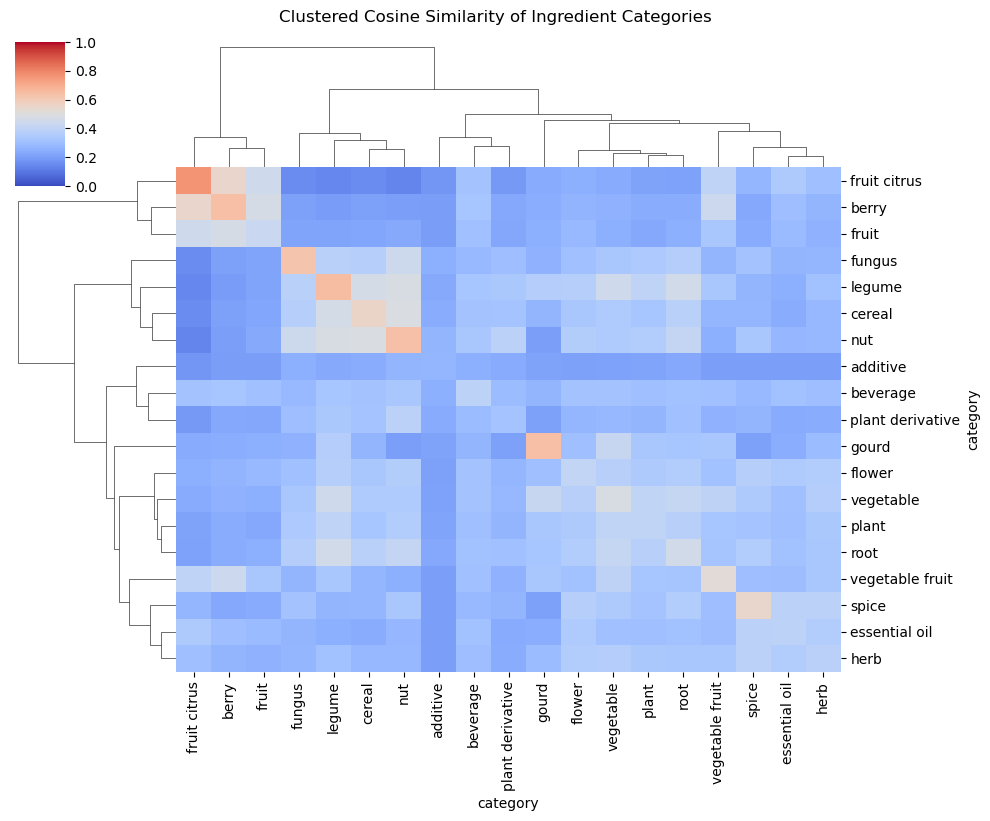

In [34]:
if config["reduce_dim"]:
    similarity_matrix = cosine_similarity_matrix(df1[desc])
    similarity_name = "cosine"
else:
    similarity_matrix = jaccard_similarity_matrix(df1[desc])
    similarity_name = "jaccard"


# Average similarity per category
# ---------------------------------------------------------
sim = similarity_matrix.copy()

sim["category"] = df1["category"].values
sim_mean = sim.groupby("category").mean()

sim_mean = sim_mean.T
sim_mean["category"] = df1["category"].values
sim_mean = sim_mean.groupby("category").mean()

g = sns.clustermap(
    sim_mean,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    method="ward",
    metric="euclidean",
    figsize=(10, 8)
)
g.fig.suptitle(f"Clustered {similarity_name.capitalize()} Similarity of Ingredient Categories", y=1.02)

save_path = "output/cat_clustered_heatmap.png"
g.savefig(save_path, dpi=config.get("dpi", 300), bbox_inches="tight")

## Quantifying category similarity

In [35]:
import os
import pandas as pd

def get_top3_categories(sim_df: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    """
    For each row in a similarity matrix, return the top 3 most similar
    categories (excluding self-similarity) and their similarity values.

    metric_name: "jaccard" or "cosine"
    """
    df = sim_df.copy()

    # Exclude self-similarity (assumes same labels on index/columns)
    # If labels don't match perfectly, this will only null where they do.
    # for idx in df.index.intersection(df.columns):
    #     df.at[idx, idx] = float("-inf")

    # Sort columns for each row and take top 3
    top3_cols = df.apply(lambda row: row.nlargest(3).index.tolist(), axis=1)
    top3_vals = df.apply(lambda row: row.nlargest(3).values.tolist(), axis=1)

    # Build output DataFrame with metric-specific column names
    out = pd.DataFrame({
        "top1_category": top3_cols.str[0],
        f"top1_{metric_name}": top3_vals.str[0],
        "top2_category": top3_cols.str[1],
        f"top2_{metric_name}": top3_vals.str[1],
        "top3_category": top3_cols.str[2],
        f"top3_{metric_name}": top3_vals.str[2],
    }, index=sim_df.index)

    return out


def to_two_level_cols(df: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    """
    Convert columns like:
      top1_category, top1_<metric>, top2_category, top2_<metric>, top3_category, top3_<metric>
    into a MultiIndex:
      ('Top 1','category'), ('Top 1','<metric> similarity'), ...
    """
    rank_map = {"top1": "Top 1", "top2": "Top 2", "top3": "Top 3"}
    new_cols = []

    metric_label = f"{metric_name} similarity"

    for c in df.columns:
        if "_" in c:
            rank, field = c.split("_", 1)
            top = rank_map.get(rank, rank.title())

            field_l = field.lower()
            if field_l == "category":
                bottom = "category"
            elif field_l.startswith(metric_name.lower()):
                bottom = metric_label
            else:
                bottom = field_l

            new_cols.append((top, bottom))
        else:
            new_cols.append(("Other", c))

    out = df.copy()
    out.columns = pd.MultiIndex.from_tuples(new_cols, names=["rank", "Reference Category"])
    return out


# ---------------------------------------------------------
# Choose metric from config
# reduce_dim True  -> cosine
# reduce_dim False -> jaccard
# ---------------------------------------------------------
metric_name = "cosine" if config["reduce_dim"] else "jaccard"

top3 = get_top3_categories(sim_mean, metric_name=metric_name)
top3_mi = to_two_level_cols(top3, metric_name=metric_name)

os.makedirs("output", exist_ok=True)
out_path = f"output/category_similarity_top3.xlsx"
top3_mi.to_excel(out_path)

top3_mi

rank                          Top 1                            Top 2  \
Reference Category         category cosine similarity       category   
category                                                               
additive                   additive          0.270008            nut   
berry                         berry          0.643112   fruit citrus   
beverage                   beverage          0.390339            nut   
cereal                       cereal          0.555206            nut   
essential oil         essential oil          0.389492          spice   
flower                       flower          0.407956      vegetable   
fruit                         berry          0.472361   fruit citrus   
fruit citrus           fruit citrus          0.765273          berry   
fungus                       fungus          0.625769            nut   
gourd                         gourd          0.644271      vegetable   
herb                          spice          0.383153           herb   
legume                       legume          0.652173            nut   
nut                             nut          0.639091         cereal   
plant                     vegetable          0.402123          plant   
plant derivative                nut          0.386271         legume   
root                           root          0.455518         legume   
spice                         spice          0.543034  essential oil   
vegetable                 vegetable          0.477303         legume   
vegetable fruit     vegetable fruit          0.516771          berry   

rank                                         Top 3                    
Reference Category cosine similarity      category cosine similarity  
category                                                              
additive                    0.267769      beverage          0.252764  
berry                       0.547905         fruit          0.472361  
beverage                    0.334429         berry          0.326943  
cereal                      0.485087        legume          0.463952  
essential oil               0.385477          herb          0.359247  
flower                      0.372430        legume          0.371054  
fruit                       0.445329         fruit          0.426117  
fruit citrus                0.547905         fruit          0.445329  
fungus                      0.439265        legume          0.377478  
gourd                       0.421133        legume          0.364203  
herb                        0.382189     vegetable          0.365551  
legume                      0.479809        cereal          0.463952  
nut                         0.485087        legume          0.479809  
plant                       0.398892        legume          0.397434  
plant derivative            0.336546        cereal          0.319780  
root                        0.454218     vegetable          0.414171  
spice                       0.385477          herb          0.383153  
vegetable                   0.447850         gourd          0.421133  
vegetable fruit             0.436937  fruit citrus          0.397426

### Compare similarity of categories between flavordb and local ingredients

In [36]:
# Compute similarity between ingredients within flavord vs local overall - checks if there is a biaised due to RAG supplemetation in local data
# Compute Jaccard similarity matrix
metric_name = "cosine" if config["reduce_dim"] else "jaccard"
sim_func = cosine_similarity_matrix if metric_name == "cosine" else jaccard_similarity_matrix

sim = sim_func(df1[desc])

# Average similarity per db
sim['db'] = df1['db'].values
# sim['category'] = df1['category'].values
sim_mean = sim.groupby('db').mean()
sim_mean = sim_mean.T
sim_mean['db'] = df1['db'].values
sim_mean = sim_mean.groupby('db').mean()

# Save
out_path = f"output/local_flavordb_general_similarity.xlsx"
sim_mean.to_excel(out_path, index=False)

sim_mean

db,flavor_db,local
db,,
flavor_db,0.305121,0.305919
local,0.305919,0.396931


In [37]:
# -----------------------------
# Compute similarity between ingredients within flavord vs local by catgories 
# -----------------------------
metric_name = "cosine" if config["reduce_dim"] else "jaccard"
sim_func = cosine_similarity_matrix if metric_name == "cosine" else jaccard_similarity_matrix

# Compute similarity matrix (ingredient-level)
sim = sim_func(df1[desc])

# Annotate
sim["db"] = df1["db"].values
sim["category"] = df1["category"].values

# categories present in local (same as your code)
shared_cat = sim.loc[sim["db"] == "local", "category"].unique()

rows = []
for cat in shared_cat:
    df2 = sim.loc[sim["category"] == cat].drop(columns="category")

    # reorder so db is last (and keep only rows in this category)
    idx = [c for c in df2.index.tolist()] + ["db"]
    df2 = df2[idx]

    # mean similarity by db (rows grouped by db)
    sim_mean = df2.groupby("db").mean()
    sim_mean = sim_mean.T
    sim_mean["db"] = df2["db"].values
    sim_mean = sim_mean.groupby("db").mean()

    # counts (safe access)
    counts = df2["db"].value_counts()
    flavor_count = int(counts.get("flavor_db", 0))
    local_count = int(counts.get("local", 0))

    # only compute if both groups exist
    if flavor_count == 0 or local_count == 0:
        continue

    flavor_vs_local = float(sim_mean.loc["flavor_db", "local"])
    flavor_vs_flavor = float(sim_mean.loc["flavor_db", "flavor_db"])
    local_vs_local = float(sim_mean.loc["local", "local"])

    rows.append({
        "category": cat,
        "flavor_vs_local": flavor_vs_local,
        "flavor_vs_flavor": flavor_vs_flavor,
        "local_vs_local": local_vs_local,
        "flavor_count": flavor_count,
        "local_count": local_count
    })

# Final comparison table
comparison_df = pd.DataFrame(rows)

# keep categories with >=3 local ingredients (same as your code)
comparison_df = comparison_df[comparison_df["local_count"] >= 3].copy()

# Save
out_path = f"output/local_flavordb_similarity.xlsx"
comparison_df.to_excel(out_path, index=False)

comparison_df

,category,flavor_vs_local,flavor_vs_flavor,local_vs_local,flavor_count,local_count
0,plant,0.358974,0.388483,0.456283,45,68
1,fungus,0.606828,0.612392,0.663790,11,14
3,vegetable,0.457377,0.483489,0.539899,41,11
4,root,0.432103,0.505452,0.466371,18,43
5,fruit,0.301432,0.453981,0.413477,81,9
6,herb,0.380897,0.376174,0.838745,51,6
7,additive,0.182427,0.294255,0.586313,25,7
9,flower,0.322625,0.447178,0.566945,9,3


# Umap

C:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


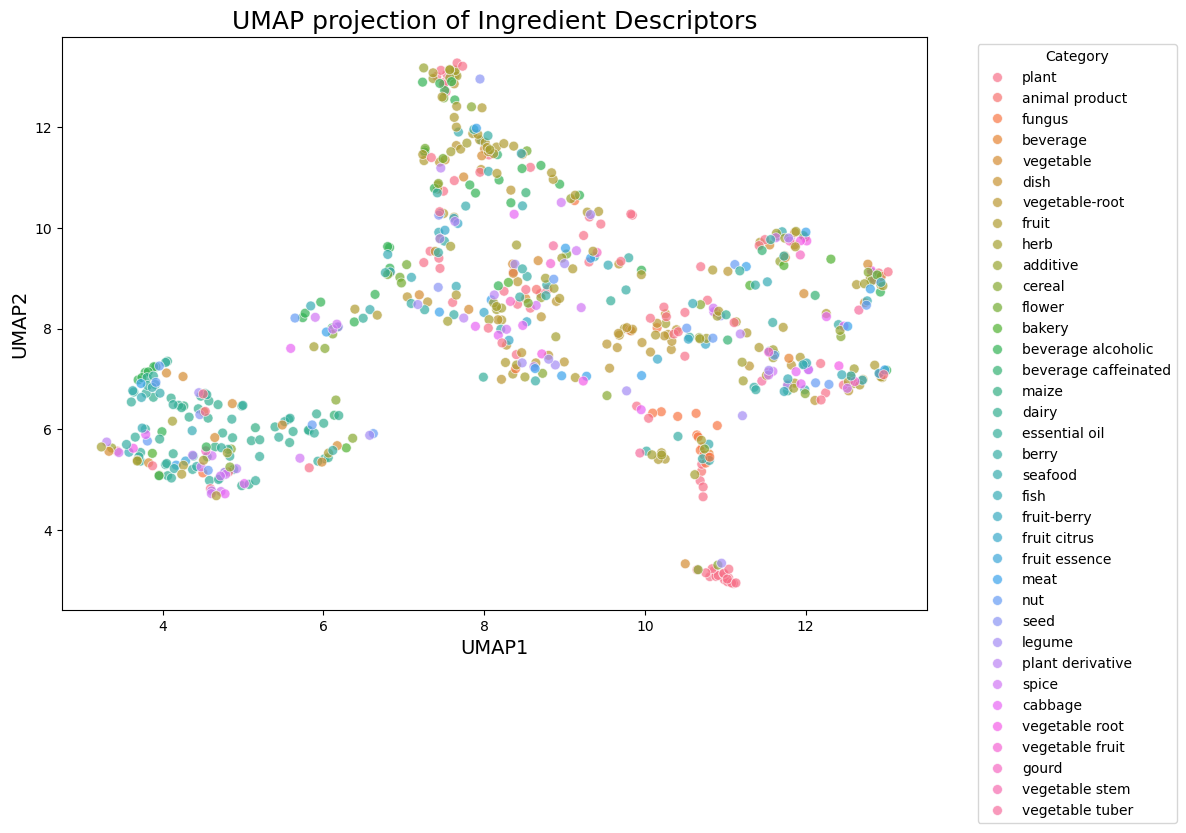

In [38]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

local = merged_df[merged_df['db'] == 'local']
local_names = local['Nom scientifique'].to_list()

df1_local = df1[df1['Nom scientifique'].isin(local_names)]
df1_local

# Separate features and the category for coloring
df_features = df1[desc]
# df_features = df1_local.drop(columns=['Nom scientifique'])
df_features = df_features.drop(columns=[col for col in df_features.columns if "cat_" in col])
categories = merged_df['category'] # Use the category from the merged_df before dropping columns

# Apply UMAP
reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(df_features)

# Create a DataFrame for plotting
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_df['category'] = categories

# Plot the UMAP embedding
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='category',
    data=umap_df,
    s=50,
    alpha=0.7
)
plt.title('UMAP projection of Ingredient Descriptors', fontsize=18)
plt.xlabel('UMAP1', fontsize=14)
plt.ylabel('UMAP2', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

if config.get("show_imp_plot", False):
    plt.show()


C:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


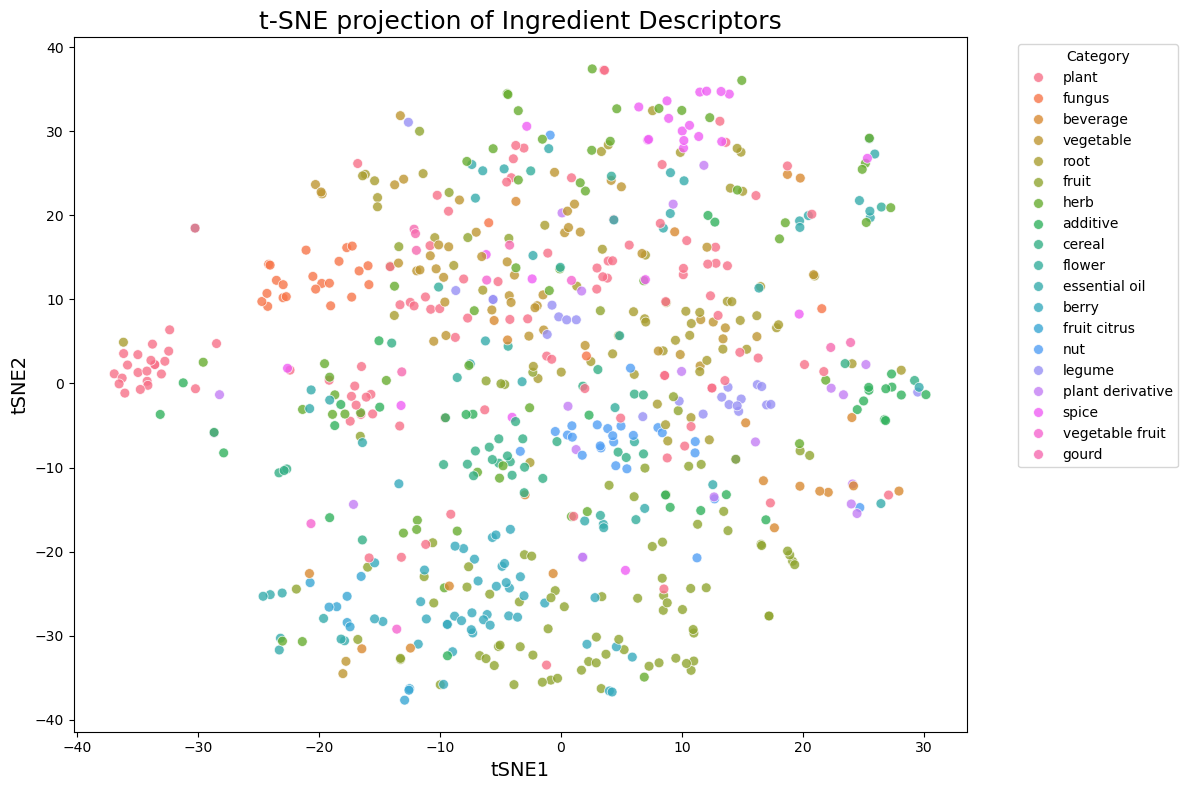

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- Build feature matrix (drop identifiers and one-hot category columns) ---
df_features = df1[desc]
df_features = df_features.drop(columns=[c for c in df_features.columns if "cat_" in c], errors='ignore')

# Keep only numeric columns (t-SNE requires numbers)
df_features = df_features.select_dtypes(include=[np.number])

# Handle NaNs
df_features = df_features.fillna(0.0)

# Optional: scale features (recommended for t-SNE)
X = StandardScaler().fit_transform(df_features.values)

# --- Align categories from merged_df to df1 rows ---
name_series = df1['Nom scientifique']
categories = df1['category']

# --- Fit t-SNE ---
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, (len(df_features) - 1) // 3)),  # decent auto heuristic
    learning_rate='auto',
    init='pca',
    metric='euclidean',
    random_state=42,
)
tsne_embedding = tsne.fit_transform(X)

# --- Prepare DataFrame for plotting ---
tsne_df = pd.DataFrame(tsne_embedding, columns=['tSNE1', 'tSNE2'])
tsne_df['category'] = categories.values

# --- Plot ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df,
    x='tSNE1',
    y='tSNE2',
    hue='category',
    s=50,
    alpha=0.8
)
plt.title('t-SNE projection of Ingredient Descriptors', fontsize=18)
plt.xlabel('tSNE1', fontsize=14)
plt.ylabel('tSNE2', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

save_path = os.path.join("output", "cat_tsne.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

if config.get("show_imp_plot", False):
    plt.show()


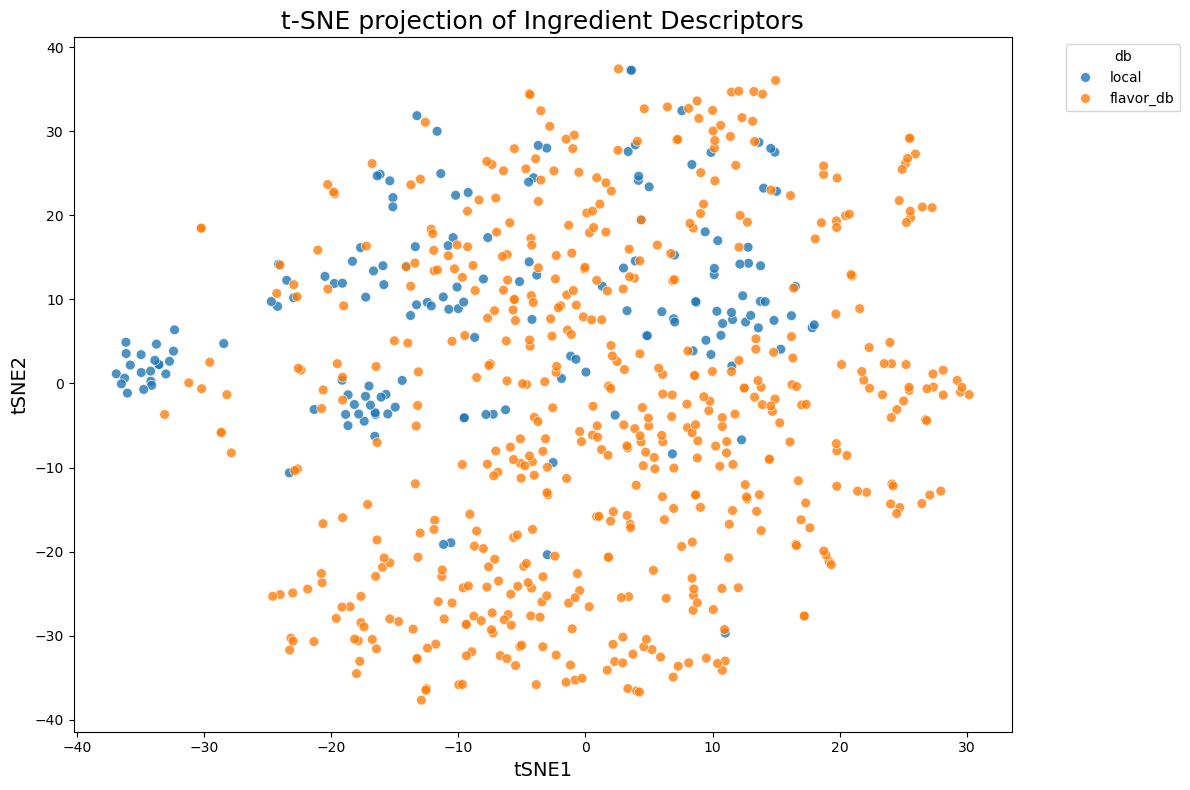

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- Build feature matrix (drop identifiers and one-hot db columns) ---
df_features = df1[desc]
df_features = df_features.drop(columns=[c for c in df_features.columns if "cat_" in c], errors='ignore')

# Keep only numeric columns (t-SNE requires numbers)
df_features = df_features.select_dtypes(include=[np.number])

# Handle NaNs
df_features = df_features.fillna(0.0)

# Optional: scale features (recommended for t-SNE)
X = StandardScaler().fit_transform(df_features.values)

# --- Align categories from merged_df to df1 rows ---
name_series = df1['Nom scientifique']
categories = df1['db']

# --- Fit t-SNE ---
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, (len(df_features) - 1) // 3)),  # decent auto heuristic
    learning_rate='auto',
    init='pca',
    metric='euclidean',
    random_state=42,
)
tsne_embedding = tsne.fit_transform(X)

# --- Prepare DataFrame for plotting ---
tsne_df = pd.DataFrame(tsne_embedding, columns=['tSNE1', 'tSNE2'])
tsne_df['db'] = categories.values

# --- Plot ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df,
    x='tSNE1',
    y='tSNE2',
    hue='db',
    s=50,
    alpha=0.8
)
plt.title('t-SNE projection of Ingredient Descriptors', fontsize=18)
plt.xlabel('tSNE1', fontsize=14)
plt.ylabel('tSNE2', fontsize=14)
plt.legend(title='db', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

save_path = os.path.join("output", "db_tsne.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

C:\Users\jpcle8\AppData\Local\miniconda3\envs\native\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


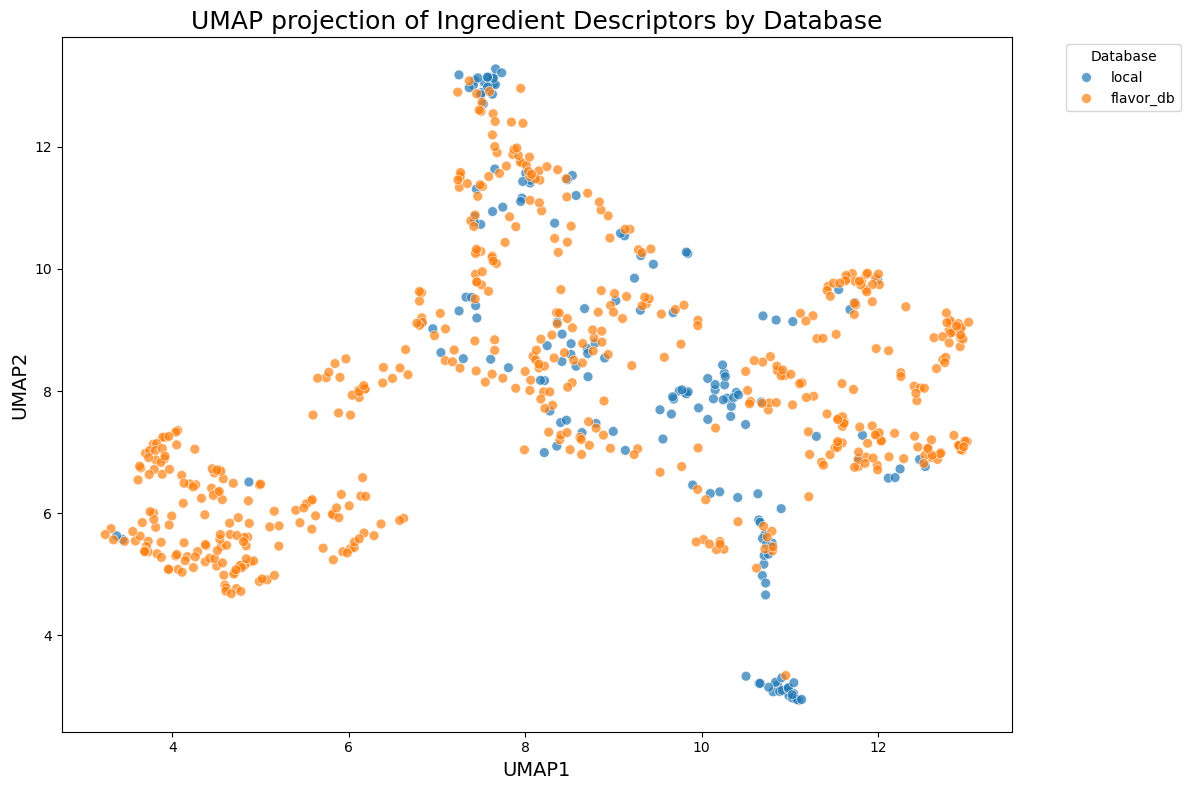

In [41]:
# Separate features and the category for coloring
df_features = df1[desc]
databases = merged_df['db'] # Use the 'db' column from the merged_df for coloring

# Apply UMAP
reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(df_features)

# Create a DataFrame for plotting
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_df['database'] = databases

# Plot the UMAP embedding
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='database',
    data=umap_df,
    s=50,
    alpha=0.7
)
plt.title('UMAP projection of Ingredient Descriptors by Database', fontsize=18)
plt.xlabel('UMAP1', fontsize=14)
plt.ylabel('UMAP2', fontsize=14)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Unsupervised learning

# KNN

In [42]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score
# import matplotlib.pyplot as plt

# # --- Features and labels ---
# X = df1[desc].values
# y = df1['category']

# # --- Split train/test ---
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # --- Scale features (important for distance-based models) ---
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # --- Test different k values ---
# k_values = range(1, 21)
# accuracies = []

# for k in k_values:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     knn.fit(X_train, y_train)
#     y_pred = knn.predict(X_test)
#     accuracies.append(accuracy_score(y_test, y_pred))

# # --- Plot accuracy vs k ---
# plt.figure(figsize=(8, 5))
# plt.plot(k_values, accuracies, marker='o')
# plt.title("KNN Classification Accuracy vs k")
# plt.xlabel("Number of Neighbors (k)")
# plt.ylabel("Accuracy")
# plt.show()


In [43]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans

# # --- Prepare feature matrix ---
# X = df1[desc].values

# # --- Standardize features (important for clustering) ---
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # --- Try several k values ---
# k_values = [3, 5, 7, 8, 10]

# # --- Run t-SNE once (expensive) ---
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# X_embedded = tsne.fit_transform(X_scaled)

# # --- Plot clusters for each k ---
# fig, axes = plt.subplots(1, len(k_values), figsize=(4*len(k_values), 4))

# for ax, k in zip(axes, k_values):
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
#     labels = kmeans.fit_predict(X_scaled)
    
#     sc = ax.scatter(
#         X_embedded[:, 0], X_embedded[:, 1],
#         c=labels, cmap='tab10', s=30, alpha=0.8
#     )
#     ax.set_title(f"K-Means (k={k})")
#     ax.set_xlabel("t-SNE 1")
#     ax.set_ylabel("t-SNE 2")

# plt.tight_layout()
# plt.show()

In [44]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans

# # --- Prepare data ---
# X = df1[desc].values
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # --- Run K-Means clustering with k=7 ---
# k = 7
# kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
# labels = kmeans.fit_predict(X_scaled)

# # --- Add cluster labels to df1 ---
# df1['cluster'] = labels

# # --- Compute cluster centroids in original feature space ---
# centroids = pd.DataFrame(
#     kmeans.cluster_centers_,
#     columns=desc
# )

# # --- For each cluster, find top descriptors (highest centroid values) ---
# top_desc_per_cluster = {}

# for i in range(k):
#     centroid = centroids.iloc[i]
#     top_features = centroid.sort_values(ascending=False).head(10).index.tolist()
#     top_desc_per_cluster[i] = top_features

# # --- Display results ---
# for cluster_id, top_feats in top_desc_per_cluster.items():
#     print(f"\n🧭 Cluster {cluster_id}: Top descriptors")
#     print(", ".join(top_feats))


In [45]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans

# # --- params ---
# k = 7
# top_n = 5                       # how many nearest ingredients to list per cluster
# feature_cols = desc             # your descriptor columns

# # --- scale & cluster (if not already done) ---
# X = df1[feature_cols].values
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
# labels = kmeans.fit_predict(X_scaled)
# centers = kmeans.cluster_centers_

# df1['cluster'] = labels

# # --- choose a display name column if available ---
# name_col = 'name' if 'name' in df1.columns else ('Nom scientifique' if 'Nom scientifique' in df1.columns else None)
# def get_label(idx):
#     if name_col is not None:
#         return df1.iloc[idx][name_col]
#     return df1.index[idx]

# # --- compute distances to own cluster centroid & pick top_n nearest ---
# nearest_per_cluster = {}
# nearest_rows = []  # for a tidy DataFrame output

# for c in range(k):
#     idx_c = np.where(labels == c)[0]
#     if len(idx_c) == 0:
#         nearest_per_cluster[c] = []
#         continue

#     Xc = X_scaled[idx_c]
#     centroid = centers[c]

#     # Euclidean distances in the scaled space
#     dists = np.linalg.norm(Xc - centroid, axis=1)
#     order = np.argsort(dists)[:min(top_n, len(idx_c))]

#     closest_indices = idx_c[order]
#     closest_names = [get_label(i) for i in closest_indices]
#     closest_dists = dists[order]

#     nearest_per_cluster[c] = list(zip(closest_names, closest_indices, closest_dists))

#     # collect rows for a tidy table
#     for name, idx_global, dist in zip(closest_names, closest_indices, closest_dists):
#         nearest_rows.append({
#             "cluster": c,
#             "ingredient": name,
#             "row_index": idx_global,
#             "distance_to_centroid": float(dist)
#         })

# # --- dict result ---
# # nearest_per_cluster: { cluster_id: [(ingredient_name, row_index, distance), ...], ... }

# # --- tidy DataFrame result (sorted) ---
# nearest_df = pd.DataFrame(nearest_rows).sort_values(["cluster", "distance_to_centroid"])
# print(nearest_df)


# Network analysis

In [46]:
# import numpy as np
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# from networkx.algorithms import community

# def plot_similarity_network(sim_df: pd.DataFrame, 
#                             threshold: float = 0.15,
#                             layout: str = "spring",
#                             figsize=(12, 10)):
#     """
#     Build and plot a network graph from a category–category similarity matrix.

#     threshold : only edges with similarity >= threshold are drawn
#     layout : "spring", "kamada", "circular"
#     """
#     df = sim_df.copy()

#     # Remove self-similarity
#     np.fill_diagonal(df.values, 0)

#     # Create graph
#     G = nx.Graph()

#     # Add nodes
#     for cat in df.index:
#         G.add_node(cat)

#     # Add edges above threshold
#     for i, cat1 in enumerate(df.index):
#         for j, cat2 in enumerate(df.columns):
#             if j <= i:
#                 continue  # avoid double counting
#             weight = df.iloc[i, j]
#             if weight >= threshold:
#                 G.add_edge(cat1, cat2, weight=weight)

#     # Compute layout
#     if layout == "spring":
#         pos = nx.spring_layout(G, seed=42, k=0.4)
#     elif layout == "kamada":
#         pos = nx.kamada_kawai_layout(G)
#     elif layout == "circular":
#         pos = nx.circular_layout(G)
#     else:
#         pos = nx.spring_layout(G, seed=42)

#     # Detect communities for node colors
#     communities = list(community.greedy_modularity_communities(G))
#     community_map = {}
#     for c_id, comm in enumerate(communities):
#         for node in comm:
#             community_map[node] = c_id

#     # Node colors based on community
#     node_colors = [community_map[n] for n in G.nodes()]

#     # Edge weights for thickness
#     edges = G.edges(data=True)
#     edge_weights = [d['weight'] * 4 for _,_,d in edges]  # scale for visibility

#     # Plot
#     plt.figure(figsize=figsize)

#     nx.draw_networkx_nodes(
#         G, pos,
#         node_size=900,
#         node_color=node_colors,
#         cmap="tab20"
#     )

#     nx.draw_networkx_edges(
#         G, pos,
#         width=edge_weights,
#         alpha=0.6
#     )

#     nx.draw_networkx_labels(
#         G, pos,
#         font_size=10,
#         font_weight="bold"
#     )

#     plt.title(f"Category Similarity Network (threshold={threshold})")
#     plt.axis("off")
#     plt.show()

#     return G

# # df_to_graph = jaccard_sim.loc[:, jaccard_sim.columns != 'category'].copy(deep = True)
# df_to_graph = jaccard_sim.loc[:, jaccard_sim.columns != 'category'].copy(deep = True)

# to_drop = [954, 1030, 385, 1134]

# df_to_graph  = df_to_graph .drop(index=to_drop, columns=to_drop)

# # ✅ Build your network graph from Jaccard similarity
# G_jaccard = plot_similarity_network(df_to_graph, threshold=0.15)
